In [3]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

def create_tendency_to_quit_dataset(base_path):
    """
    Create a dataset for modeling the tendency to quit the game.
    """
    print("🚀 Oyunu bırakma eğilimi veri seti oluşturma süreci başladı...")

    # --- 1. Veri Yükleme ---
    print("📂 Ham veri dosyaları yükleniyor...")

    required_files = {
        "demographics": "demographics.xlsx",
        "first_login": "first_time_login.xlsx",
        "session_data": "session_data.xlsx",
        "ads_viewed": "ads_viewed.xlsx",
        "iap_data": "iap_data.xlsx",
        "avg_level_completion_time": "avg_level_completation_time.xlsx",
        "level_completion_rate": "level_completion_rate_v2.xlsx",
        "quit_label": "quit_label.xlsx"
    }

    # Load each file, and handle missing ones gracefully
    try:
        demographics = pd.read_excel(os.path.join(base_path, required_files["demographics"]))
        first_login = pd.read_excel(os.path.join(base_path, required_files["first_login"]))
        session_data = pd.read_excel(os.path.join(base_path, required_files["session_data"]))
        ads_viewed = pd.read_excel(os.path.join(base_path, required_files["ads_viewed"]))
        iap_data = pd.read_excel(os.path.join(base_path, required_files["iap_data"]))
        avg_level_completion_time = pd.read_excel(os.path.join(base_path, required_files["avg_level_completion_time"]))
        level_completion_rate = pd.read_excel(os.path.join(base_path, required_files["level_completion_rate"]))
        quit_label = pd.read_excel(os.path.join(base_path, required_files["quit_label"]))
    except FileNotFoundError as e:
        print(f"❌ HATA: Gerekli bir dosya bulunamadı -> {e.filename}")
        return None

    # --- 2. Veri Birleştirme ---
    print("🔗 Veri setleri birleştiriliyor...")
    dataframes = [
        first_login, session_data, ads_viewed, iap_data,
        avg_level_completion_time, level_completion_rate, quit_label
    ]
    merged_df = demographics
    for df in dataframes:
        merged_df = pd.merge(merged_df, df, on='user_key_id', how='left')

    print("✅ Birleştirme tamamlandı.")
    return merged_df


In [4]:
base_path = "../data/raw"
merged_df = create_tendency_to_quit_dataset(base_path)

if merged_df is not None:
    display(merged_df.head())


🚀 Oyunu bırakma eğilimi veri seti oluşturma süreci başladı...
📂 Ham veri dosyaları yükleniyor...
🔗 Veri setleri birleştiriliyor...
✅ Birleştirme tamamlandı.


,user_key_id,country,age,sex,first_time_login,session_count,total_session_time_x,total_ad_viewed,total_spent_in_usd,total_spent_time,total_session_time_y,level_completion_count,avg_level_completion_time,easy_completion_rate,medium_completion_rate,hard_completion_rate,is_quit
0,bVas4SMsXQ,GB,30.0,1.0,2025-02-25 20:54:15.172139 +00:00,86.0,52464.0,15.0,14.0,3.0,52464.0,9.0,5829.333333,100.0,100.0,25.0,0.0
1,08jRAlDfJC,US,70.0,1.0,2025-02-21 15:38:43.063737 +00:00,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,100.0,25.0,0.0,NaN
2,QujP57B9cB,DE,NaN,NaN,2025-02-22 02:41:22.209045 +00:00,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,100.0,75.0,0.0,NaN
3,Hm917zE2Mc,GB,36.0,0.0,2025-03-28 15:54:29.704067 +00:00,10.0,4202.0,5.0,16.8,4.0,4202.0,4.0,1050.500000,100.0,50.0,0.0,0.0
4,wFfzWC1Ydt,US,40.0,1.0,2025-03-09 02:16:18.684862 +00:00,62.0,75586.0,23.0,NaN,NaN,75586.0,6.0,12597.666667,100.0,100.0,0.0,1.0


In [5]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5100.0,39.822549,11.231648,18.0,32.00,39.0,47.000000,9.900000e+01
sex,5049.0,0.573579,0.575331,0.0,0.00,1.0,1.000000,2.000000e+00
session_count,5206.0,27.005570,52.499985,1.0,2.00,7.0,27.000000,6.240000e+02
total_session_time_x,5206.0,43371.198233,106957.365393,0.0,1838.00,8536.0,38571.750000,1.699008e+06
total_ad_viewed,5889.0,56.155035,155.379985,1.0,1.00,3.0,28.000000,1.788000e+03
total_spent_in_usd,1282.0,9.842987,11.006440,1.4,4.00,4.0,14.000000,8.430002e+01
total_spent_time,1282.0,2.226989,2.713621,1.0,1.00,1.0,3.000000,2.300000e+01
total_session_time_y,4648.0,47138.809811,110333.540235,0.0,2531.75,10604.5,43774.000000,1.699008e+06
level_completion_count,4648.0,4.753873,2.741987,1.0,3.00,4.0,6.000000,1.500000e+01
avg_level_completion_time,4648.0,7408.221022,19453.647920,0.0,989.75,2631.8,7325.392857,6.479730e+05


In [6]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                8763 non-null   object 
 1   country                    8763 non-null   object 
 2   age                        5100 non-null   float64
 3   sex                        5049 non-null   float64
 4   first_time_login           8763 non-null   object 
 5   session_count              5206 non-null   float64
 6   total_session_time_x       5206 non-null   float64
 7   total_ad_viewed            5889 non-null   float64
 8   total_spent_in_usd         1282 non-null   float64
 9   total_spent_time           1282 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       6877 non-null   float

In [7]:
# Filter users where 'avg_level_completion_time' is not null
filtered_df = merged_df[merged_df['avg_level_completion_time'].notnull()]

# Display the filtered data to the user
filtered_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        3361 non-null   float64
 3   sex                        3338 non-null   float64
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            3929 non-null   float64
 8   total_spent_in_usd         1155 non-null   float64
 9   total_spent_time           1155 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4641 non-null   float64
 1

In [8]:
# Map the 'sex' column: 0 -> 'Women', 1 -> 'Men'
filtered_df['sex'] = filtered_df['sex'].map({0: 'Women', 1: 'Men'})

filtered_df.head()

/var/folders/4g/k36svxd51cxdn1qcwnzvrbsc0000gn/T/ipykernel_90468/2574785056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['sex'] = filtered_df['sex'].map({0: 'Women', 1: 'Men'})


,user_key_id,country,age,sex,first_time_login,session_count,total_session_time_x,total_ad_viewed,total_spent_in_usd,total_spent_time,total_session_time_y,level_completion_count,avg_level_completion_time,easy_completion_rate,medium_completion_rate,hard_completion_rate,is_quit
0,bVas4SMsXQ,GB,30.0,Men,2025-02-25 20:54:15.172139 +00:00,86.0,52464.0,15.0,14.0,3.0,52464.0,9.0,5829.333333,100.0,100.0,25.0,0.0
3,Hm917zE2Mc,GB,36.0,Women,2025-03-28 15:54:29.704067 +00:00,10.0,4202.0,5.0,16.8,4.0,4202.0,4.0,1050.500000,100.0,50.0,0.0,0.0
4,wFfzWC1Ydt,US,40.0,Men,2025-03-09 02:16:18.684862 +00:00,62.0,75586.0,23.0,NaN,NaN,75586.0,6.0,12597.666667,100.0,100.0,0.0,1.0
5,73S29MCQWv,DE,NaN,NaN,2025-03-07 07:44:10.216009 +00:00,13.0,23024.0,3.0,NaN,NaN,23024.0,5.0,4604.800000,100.0,75.0,0.0,1.0
7,B4A9tTZMAE,US,21.0,Women,2025-02-01 02:21:45.626755 +00:00,2.0,983.0,1.0,NaN,NaN,983.0,2.0,491.500000,100.0,0.0,0.0,1.0


In [9]:
# Calculate the count and rate of each gender
gender_counts = filtered_df['sex'].value_counts(dropna=True)
gender_rate = (gender_counts / gender_counts.sum()) * 100

# Combine both count and rate into a DataFrame
gender_stats = pd.DataFrame({
    'Count': gender_counts,
    'Rate (%)': gender_rate.round(2)
})

gender_stats

,Count,Rate (%)
sex,,
Men,1648,51.56
Women,1548,48.44


In [10]:
# Create a copy of the DataFrame to preserve the original
df_sex_imputed = filtered_df.copy()

# Get current distribution of 'sex' values
sex_distribution = df_sex_imputed['sex'].value_counts(normalize=True)

# Get indices where 'sex' is NaN
nan_indices = df_sex_imputed[df_sex_imputed['sex'].isna()].index

# Randomly assign 'Men' or 'Women' based on the observed distribution
imputed_values = np.random.choice(
    sex_distribution.index,
    size=len(nan_indices),
    p=sex_distribution.values
)

# Fill the NaN values
df_sex_imputed.loc[nan_indices, 'sex'] = imputed_values

df_sex_imputed['sex'].info()

df_sex_imputed.info()




<class 'pandas.core.series.Series'>
Index: 4648 entries, 0 to 8762
Series name: sex
Non-Null Count  Dtype 
--------------  ----- 
4648 non-null   object
dtypes: object(1)
memory usage: 201.7+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        3361 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            3929 non-null   float64
 8   total_spent_in_usd         1155 non-null   float64
 9   total_spent_time           1155 non-null   float64
 10  total_session_time_y      

In [11]:
median_age = df_sex_imputed['age'].median()
mean_age = df_sex_imputed['age'].mean()
print(f"MedianAge: {median_age} , MeanAge: {mean_age}")

MedianAge: 39.0 , MeanAge: 39.633442427848856


In [12]:
df_age_imputed = df_sex_imputed.copy()
df_age_imputed['age'] = df_age_imputed.groupby('sex')['age'].transform(lambda x: x.fillna(x.median()))

In [13]:
df_age_imputed.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4648.0,39.458046,9.285073,18.0,35.00,39.0,43.000000,9.900000e+01
session_count,4646.0,29.016143,53.316355,1.0,3.00,9.0,29.000000,6.140000e+02
total_session_time_x,4646.0,47128.468145,110310.968381,0.0,2533.75,10602.5,43808.000000,1.699008e+06
total_ad_viewed,3929.0,67.354034,167.548651,1.0,1.00,5.0,45.000000,1.709000e+03
total_spent_in_usd,1155.0,10.031004,11.101345,1.4,4.00,4.0,14.000000,8.430002e+01
total_spent_time,1155.0,2.264935,2.745554,1.0,1.00,1.0,3.000000,2.300000e+01
total_session_time_y,4648.0,47138.809811,110333.540235,0.0,2531.75,10604.5,43774.000000,1.699008e+06
level_completion_count,4648.0,4.753873,2.741987,1.0,3.00,4.0,6.000000,1.500000e+01
avg_level_completion_time,4648.0,7408.221022,19453.647920,0.0,989.75,2631.8,7325.392857,6.479730e+05
easy_completion_rate,4641.0,93.977591,16.275998,50.0,100.00,100.0,100.000000,1.000000e+02


In [ ]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        4648 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            3929 non-null   float64
 8   total_spent_in_usd         1155 non-null   float64
 9   total_spent_time           1155 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4641 non-null   float64
 1

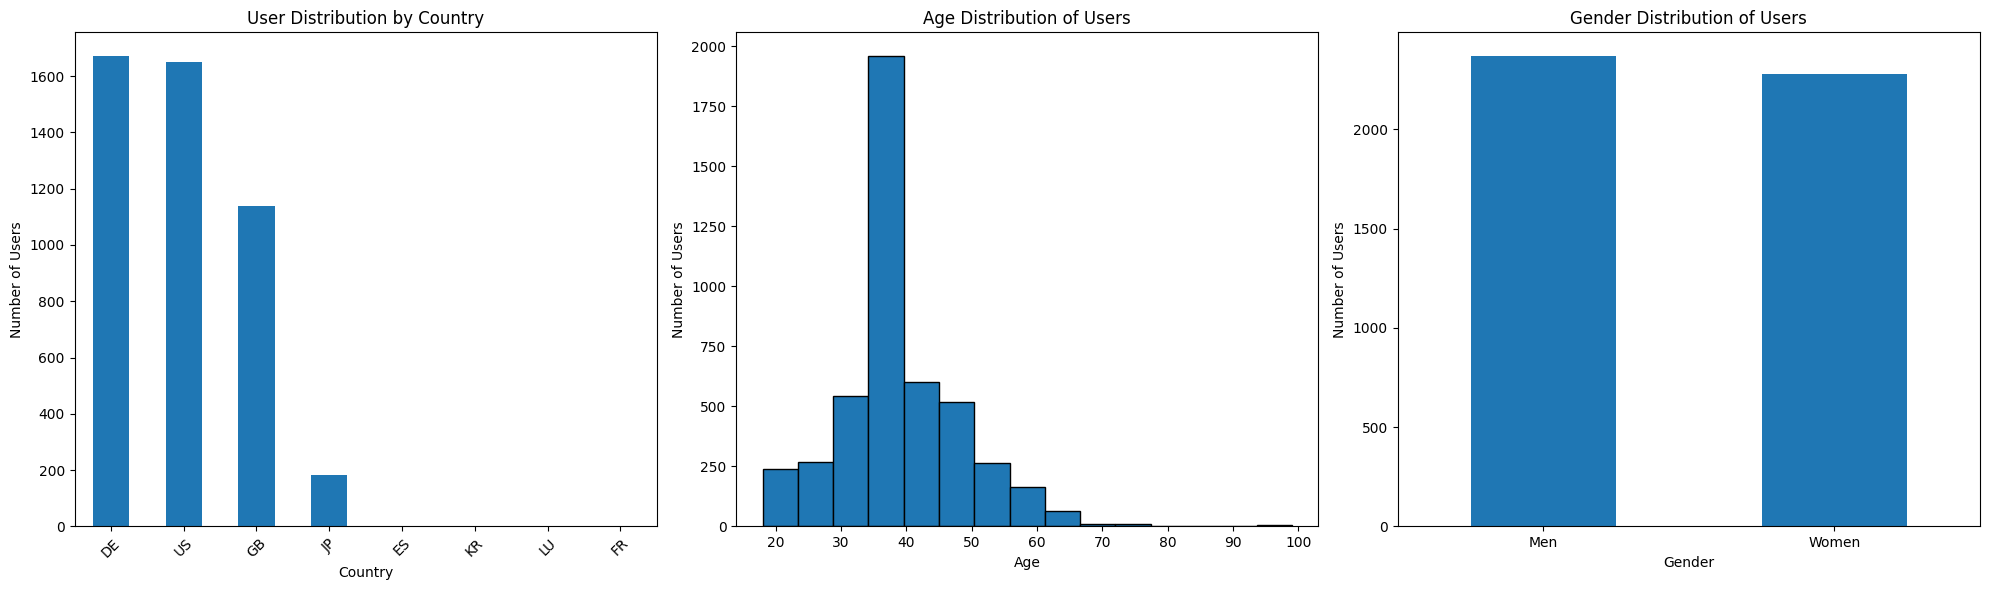

In [15]:
import matplotlib.pyplot as plt

# Creating subplots to show all three demographics in one figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Country distribution
df_age_imputed['country'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('User Distribution by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=45)

# Age distribution
df_age_imputed['age'].plot(kind='hist', bins=15, edgecolor='black', ax=axes[1])
axes[1].set_title('Age Distribution of Users')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Users')

# Gender distribution
df_age_imputed['sex'].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title('Gender Distribution of Users')
axes[2].set_xlabel('Gender')
axes[2].set_ylabel('Number of Users')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


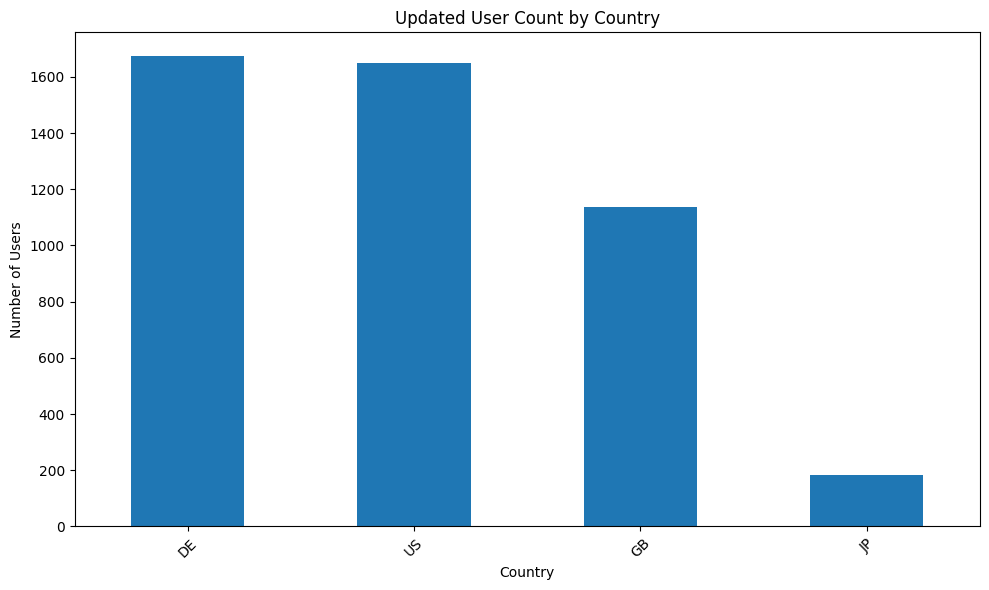

In [16]:
# Updating country values based on the user's rules
df_age_imputed['country'] = df_age_imputed['country'].replace({
    'ES': 'DE',
    'FR': 'DE',
    'KR': 'JP',
    'LU': 'JP'
})

# Recalculating user count by country after the update
updated_user_count_by_country = df_age_imputed['country'].value_counts().reset_index()
updated_user_count_by_country.columns = ['country', 'user_count']

# Display updated chart
plt.figure(figsize=(10, 6))
updated_user_count_by_country.set_index('country')['user_count'].plot(kind='bar')
plt.title('Updated User Count by Country')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/4g/k36svxd51cxdn1qcwnzvrbsc0000gn/T/ipykernel_90468/1984405051.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_age_imputed.groupby(['country', 'age_category']).size().unstack(fill_value=0)


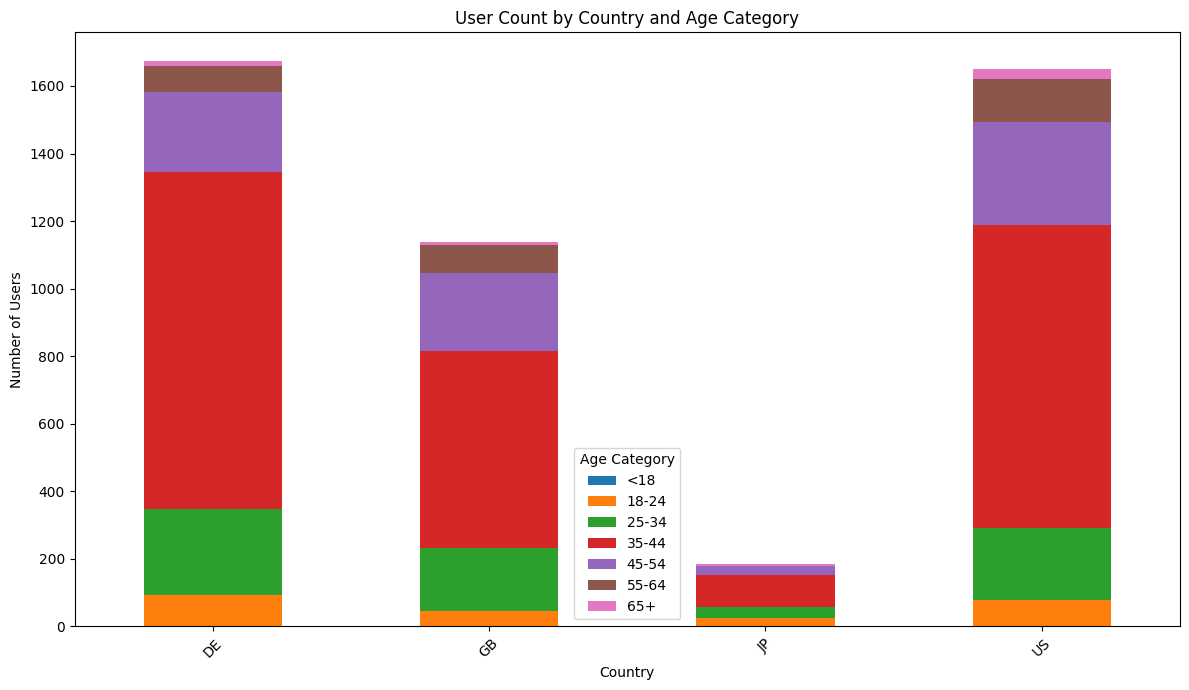

In [17]:
# Define age categories
bins = [0, 17, 24, 34, 44, 54, 64, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df_age_imputed['age_category'] = pd.cut(df_age_imputed['age'], bins=bins, labels=labels, right=False)

# Group by country and age category
grouped = df_age_imputed.groupby(['country', 'age_category']).size().unstack(fill_value=0)

# Plotting a stacked bar chart
grouped.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('User Count by Country and Age Category')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Age Category')
plt.tight_layout()
plt.show()


In [18]:
# Remove the 'age_category' column from the dataframe
df_age_imputed.drop(columns=['age_category'], inplace=True)

# Confirm it's removed by showing the current columns
df_age_imputed.columns

Index(['user_key_id', 'country', 'age', 'sex', 'first_time_login',
       'session_count', 'total_session_time_x', 'total_ad_viewed',
       'total_spent_in_usd', 'total_spent_time', 'total_session_time_y',
       'level_completion_count', 'avg_level_completion_time',
       'easy_completion_rate', 'medium_completion_rate',
       'hard_completion_rate', 'is_quit'],
      dtype='object')

In [19]:
# Fill NaN values in 'total_spent_in_usd' and 'total_spent_time' with 0
df_age_imputed[['total_spent_in_usd', 'total_spent_time']] = df_age_imputed[['total_spent_in_usd', 'total_spent_time']].fillna(0)

# Check that there are no more nulls in those columns
df_age_imputed[['total_spent_in_usd', 'total_spent_time']].isnull().sum()


total_spent_in_usd    0
total_spent_time      0
dtype: int64

In [20]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        4648 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            3929 non-null   float64
 8   total_spent_in_usd         4648 non-null   float64
 9   total_spent_time           4648 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4641 non-null   float64
 1

In [21]:
median_total_ad_viewed = df_age_imputed['total_ad_viewed'].median()
mean_total_ad_viewed = df_age_imputed['total_ad_viewed'].mean()
print(f"MedianTotalAdViewed: {median_total_ad_viewed} , MeanTotalAdViewed: {mean_total_ad_viewed}")

MedianTotalAdViewed: 5.0 , MeanTotalAdViewed: 67.35403410537032


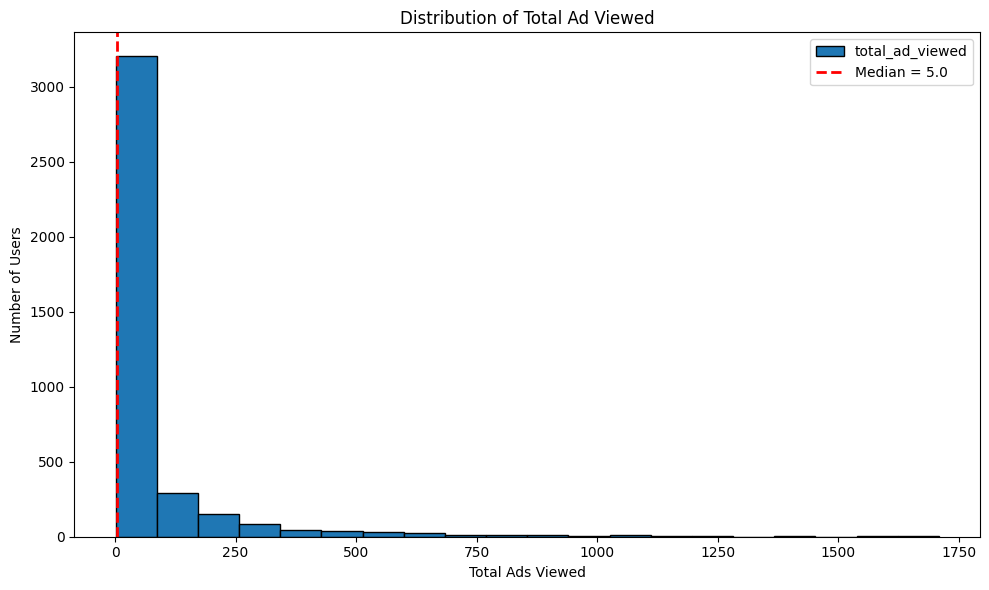

In [22]:
# Showing distribution again with a focus on clearer bins
plt.figure(figsize=(10, 6))
df_age_imputed['total_ad_viewed'].plot(kind='hist', bins=20, edgecolor='black')
plt.axvline(median_total_ad_viewed, color='red', linestyle='dashed', linewidth=2, label=f'Median = {median_total_ad_viewed}')
plt.title('Distribution of Total Ad Viewed')
plt.xlabel('Total Ads Viewed')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# Fill null values in 'total_ad_viewed' with the median
df_age_imputed['total_ad_viewed'].fillna(median_total_ad_viewed, inplace=True)

# Confirm there are no nulls left
df_age_imputed['total_ad_viewed'].isnull().sum()


np.int64(0)

In [24]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        4648 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            4648 non-null   float64
 8   total_spent_in_usd         4648 non-null   float64
 9   total_spent_time           4648 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4641 non-null   float64
 1

In [25]:
# Fill null values in completion rate columns with 0
completion_columns = ['easy_completion_rate', 'medium_completion_rate', 'hard_completion_rate']
df_age_imputed[completion_columns] = df_age_imputed[completion_columns].fillna(0)

# Confirm no nulls remain in those columns
df_age_imputed[completion_columns].isnull().sum()


easy_completion_rate      0
medium_completion_rate    0
hard_completion_rate      0
dtype: int64

In [26]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        4648 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            4648 non-null   float64
 8   total_spent_in_usd         4648 non-null   float64
 9   total_spent_time           4648 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4648 non-null   float64
 1

In [27]:
df_age_imputed.columns

Index(['user_key_id', 'country', 'age', 'sex', 'first_time_login',
       'session_count', 'total_session_time_x', 'total_ad_viewed',
       'total_spent_in_usd', 'total_spent_time', 'total_session_time_y',
       'level_completion_count', 'avg_level_completion_time',
       'easy_completion_rate', 'medium_completion_rate',
       'hard_completion_rate', 'is_quit'],
      dtype='object')

In [28]:
df_age_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4648 entries, 0 to 8762
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_key_id                4648 non-null   object 
 1   country                    4648 non-null   object 
 2   age                        4648 non-null   float64
 3   sex                        4648 non-null   object 
 4   first_time_login           4648 non-null   object 
 5   session_count              4646 non-null   float64
 6   total_session_time_x       4646 non-null   float64
 7   total_ad_viewed            4648 non-null   float64
 8   total_spent_in_usd         4648 non-null   float64
 9   total_spent_time           4648 non-null   float64
 10  total_session_time_y       4648 non-null   float64
 11  level_completion_count     4648 non-null   float64
 12  avg_level_completion_time  4648 non-null   float64
 13  easy_completion_rate       4648 non-null   float64
 1

In [49]:
# Filter out users with missing 'total_session_time_x' values
df_final = df_age_imputed[df_age_imputed['total_session_time_x'].notnull()].copy()

# Display number of users before and after filtering
original_count = len(df_age_imputed)
filtered_count = len(df_final)
original_count, filtered_count


(4648, 4646)

In [29]:
base_processed_path = "../data/processed"
df_age_imputed.to_excel(os.path.join(base_processed_path, "filtered_final_ml_excel_churn_predictor.xlsx"), index=False)
df_age_imputed.to_csv(os.path.join(base_processed_path, "filtered_final_ml_excel_churn_predictor.csv"), index=False)

In [30]:
from sklearn.preprocessing import LabelEncoder

# Drop columns with null values
df_cleaned = df_age_imputed.dropna(axis=1)

# Drop one of the duplicate columns (keep total_session_time_x)
if 'total_session_time_y' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop(columns=['total_session_time_y'])

# Convert 'first_time_login' to datetime and then to days since first login
df_cleaned['first_time_login'] = pd.to_datetime(df_cleaned['first_time_login'])
min_login = df_cleaned['first_time_login'].min()
df_cleaned['days_since_first_login'] = (df_cleaned['first_time_login'] - min_login).dt.days
df_cleaned = df_cleaned.drop(columns=['first_time_login'])

# Encode categorical variables
label_encoders = {}
for col in ['country', 'sex']:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])
    label_encoders[col] = le

# Drop identifier column
df_cleaned = df_cleaned.drop(columns=['user_key_id'])

# Separate features and target
X = df_cleaned.drop(columns=['is_quit'])
y = df_cleaned['is_quit']



X.shape, y.shape

((4648, 12), (4648,))

In [31]:
base_processed_path = "../data/processed"
df_cleaned.to_excel(os.path.join(base_processed_path, "filtered_final_ml_excel_churn_predictor_for_ml.xlsx"), index=False)
df_cleaned.to_csv(os.path.join(base_processed_path, "filtered_final_ml_excel_churn_predictor_for_ml.csv"), index=False)